**<span style="font-size:20px; color: LightBlue;">This file is created for XGBoost modeling</span>**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('creditcard.csv')

**<span style="font-size:20px; color: LightBlue;">Function to split features and target variable, preprocess data, and return train-test splits</span>**

In [30]:
# Function to slpit the data into train and test data
def splitFeatureTarget():

    X = df.drop('Class', axis=1)
    y = df['Class']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print("\n Train shape:", X_train.shape, "Test shape:", X_test.shape)
    print("\n Class distribution in train:\n", y_train.value_counts())
    print("\n Class distribution in test:\n", y_test.value_counts())
    return X_train, X_test, y_train, y_test

**<span style="font-size:20px; color: LightBlue;">Function to evaluate model performance using various metrics</span>**

In [32]:
#Function created which performs the following tasks:
#1. Training model to output a prediction for each observation
#2. Evaluating the model performance using accuracy, confusion matrix, and classification report
#3. Printing the model performance metrics
#4. Plotting the confusion matrix

def evaluateModelPerf(model, X_test, y_test):
    # Performing step #1
    y_pred = model.predict(X_test)

    # Performing step #2
    accuracy = accuracy_score(y_test, y_pred)
    #matrix = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred,digits=4)

    # Performing step #3
    print("\n Accuracy:", accuracy)
    print("\n Classification Report:\n", report)
    print("\n Confusion Matrix:")

    # Performing step #4
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    disp.figure_.set_size_inches(4, 4)
    plt.show()

**<span style="font-size:20px; color: LightBlue;">Function to create ROC AUC curve for the model</span>**

In [ ]:
#Function created which performs the following tasks:
#1. Predicting probabilities of class 1 on model
#2. Calculating ROC curve and AUC using inbuilt functions
#3. Plotting and displaying ROC AUC curve
#4. Creating legend and grid for the plot for better visualization

def createRocAucCurve(y_test,y_probability):
    
    # Performing step #1 in main function itself and passing values to this caller function
    #y_probability = model.predict_proba(X_test)[:, 1]  
    #svm_scores = model.decision_function(X_test)

    # Performing step #2
    roc_auc = roc_auc_score(y_test, y_probability)
    print(f"ROC-AUC: {roc_auc:.4f}")
    

    precision, recall, thresholds = precision_recall_curve(y_test, y_probability)
    pr_auc = auc(recall, precision)
    print(f"PR AUC: {pr_auc:.4f}")
    
    # Ploting Precision-Recall curve
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve (XGBoost Model)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

**<span style="font-size:30px; color: LightBlue;">Implementation of XGBoost Model</span>**


 Train shape: (227845, 30) Test shape: (56962, 30)

 Class distribution in train:
 Class
0    227451
1       394
Name: count, dtype: int64

 Class distribution in test:
 Class
0    56864
1       98
Name: count, dtype: int64
------------

 Accuracy: 0.996295776131456

 Classification Report:
               precision    recall  f1-score   support

           0     0.9998    0.9965    0.9981     56864
           1     0.3031    0.8878    0.4519        98

    accuracy                         0.9963     56962
   macro avg     0.6515    0.9421    0.7250     56962
weighted avg     0.9986    0.9963    0.9972     56962


 Confusion Matrix:


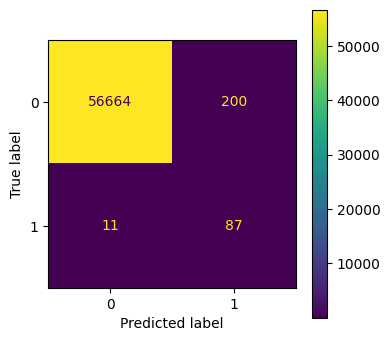

ROC-AUC: 0.9782
PR AUC: 0.8405


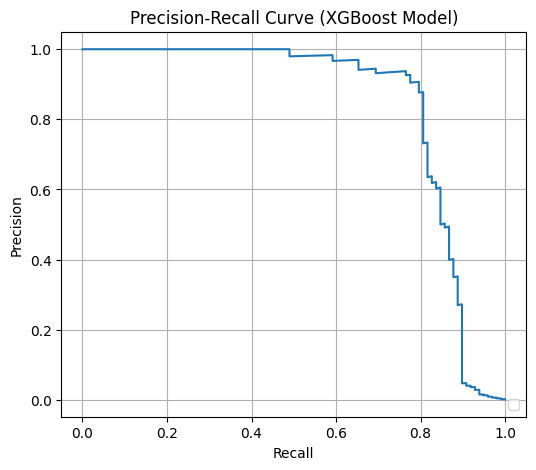

In [35]:
X_train, X_test, y_train, y_test = splitFeatureTarget()

xgb_pipeline = ImbPipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
xgb_pipeline.fit(X_train, y_train)

y_probability = xgb_pipeline.predict_proba(X_test)[:, 1]  

print("------------")
evaluateModelPerf(xgb_pipeline,X_test, y_test)

# Calling the function to create ROC AUC curve for the model 
createRocAucCurve(y_test,y_probability)

**<span style="font-size:30px; color: LightBlue;">Implementation of Hypertuned XGBoost Model</span>**

In [37]:
#Function created which performs the following tasks for tuned model:
#1. Evaluating the model performance using confusion matrix, and classification report
#2. Printing the model performance metrics
#3. Plotting the confusion matrix
#4. Calculating and Plotting ROC-AUC curve
def evaluateModelPerfTune(y_true, y_pred, y_scores=None, model_name="Model"):
    print(f"\n{model_name} Evaluation\n")
    
    #Performing step 2
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    #Performing step 3
    print("\n Confusion Matrix:")
    disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    disp.figure_.set_size_inches(4, 4)
    plt.show()
    
    #Performing step 4
    if y_scores is not None:
        # ROC-AUC
        roc_auc = roc_auc_score(y_true, y_scores)
        print(f"ROC-AUC: {roc_auc:.4f}")
        
        # Precision-Recall AUC
        precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
        pr_auc = auc(recall, precision)
        print(f"PR AUC: {pr_auc:.4f}")
        
        # Ploting Precision-Recall curve
        plt.figure(figsize=(6,5))
        plt.plot(recall, precision)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall Curve ({model_name})")
        plt.grid(True)
        plt.show()


Threshold Tuning (XGBoost)
Best threshold: 0.99
Best F1 (fraud class): 0.8427
Precision at best F1: 0.9375
Recall at best F1:    0.7653

XGBoost (threshold=0.99) Evaluation


Classification Report:
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9375    0.7653    0.8427        98

    accuracy                         0.9995     56962
   macro avg     0.9685    0.8826    0.9212     56962
weighted avg     0.9995    0.9995    0.9995     56962


 Confusion Matrix:


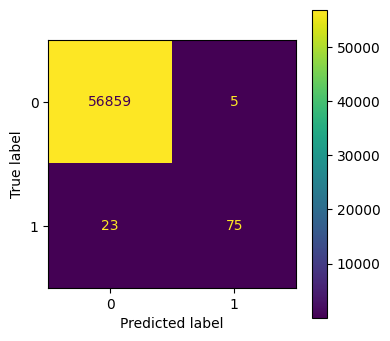

ROC-AUC: 0.9782
PR AUC: 0.8405


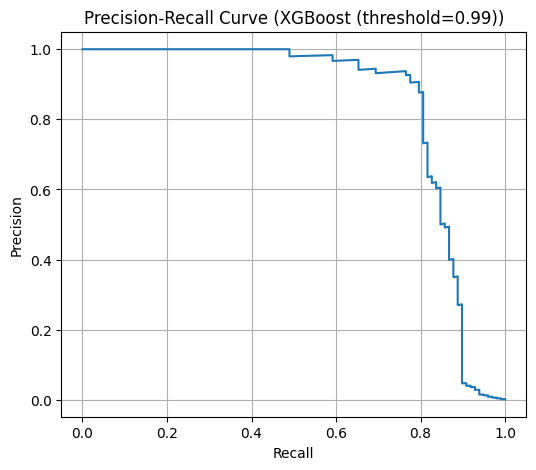

In [39]:
# Creating array of multiple threshold values
thresholds = np.linspace(0.01, 0.99, 99, 0.98)

best_f1 = 0
best_threshold = 0.5
best_precision = 0
best_recall = 0

# Extract P/R/F1 for positive class with best threshold
for thr in thresholds:
    y_pred_thr = (y_probability >= thr).astype(int)
    report = classification_report(y_test, y_pred_thr, output_dict=True)
    f1 = report['1']['f1-score']
    precision = report['1']['precision']
    recall = report['1']['recall']
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thr
        best_precision = precision
        best_recall = recall

#Printing the results with best threshold
print("\nThreshold Tuning (XGBoost)")
print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1 (fraud class): {best_f1:.4f}")
print(f"Precision at best F1: {best_precision:.4f}")
print(f"Recall at best F1:    {best_recall:.4f}")

# Evaluating once more using best threshold
y_pred_best_thr = (y_probability >= best_threshold).astype(int)

#Saving the variable for final model comparisons
np.save("results/xgb_y_prob.npy", y_probability)

#Calling function to evaluate the model with best threshold
evaluateModelPerfTune(y_test, y_pred_best_thr, y_probability,
               model_name=f"XGBoost (threshold={best_threshold:.2f})")
